In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st

In [ ]:
# Parámetros
n, x = 100, 18
a, b = 4, 16
a_post, b_post = a + x, b + n - x  # 22, 98

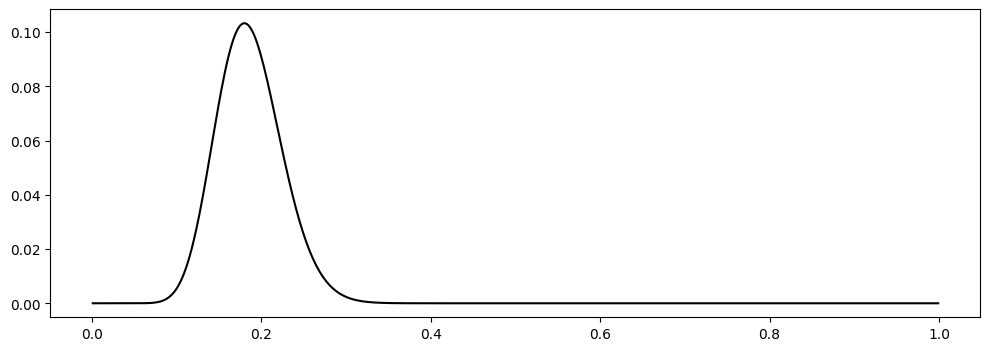

In [13]:
# a) Función de verosimilitud (normalizada para visualización)
theta = np.linspace(0.001, 0.999, 500)
L = st.binom.pmf(x, n, theta)

plt.figure(figsize=(6*2, 4))
plt.plot(theta, L, 'k-', lw=1.5, label='Verosimilitud');

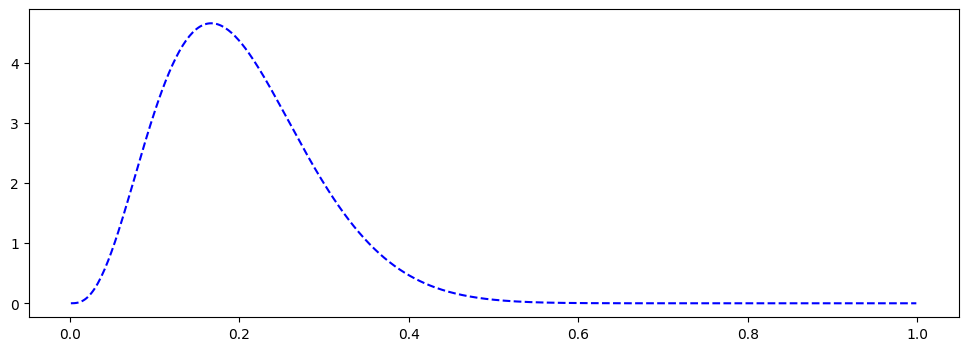

In [20]:
# b) Densidad a priori
prior = st.beta(a, b).pdf(theta)
plt.figure(figsize=(6*2, 4))
plt.plot(theta, prior, 'b--', lw=1.5, label=f'Prior Beta({a},{b})');

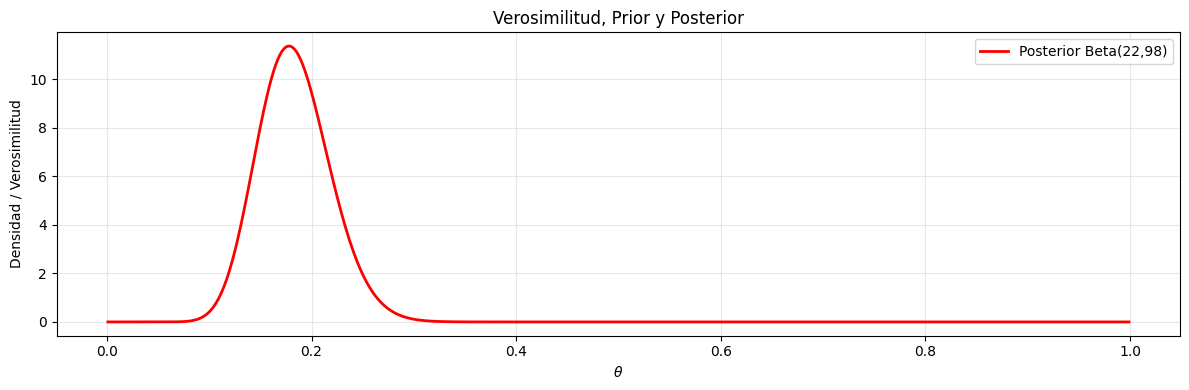

In [21]:
# c) Densidad posterior
posterior = st.beta(a_post, b_post).pdf(theta)
plt.figure(figsize=(6*2, 4))
plt.plot(theta, posterior, 'r-', lw=2, label=f'Posterior Beta({a_post},{b_post})')

plt.xlabel(r'$\theta$')
plt.ylabel('Densidad / Verosimilitud')
plt.title('Verosimilitud, Prior y Posterior')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# d) Media, varianza y moda de la posterior
media = a_post / (a_post + b_post)
var   = (a_post * b_post) / ((a_post + b_post)**2 * (a_post + b_post + 1))
moda  = (a_post - 1) / (a_post + b_post - 2)

print(f"Posterior Beta({a_post}, {b_post})")
print(f"Media  : {media:.4f}")
print(f"Varianza: {var:.6f}")
print(f"Moda   : {moda:.4f}")

Posterior Beta(22, 98)
Media  : 0.1833
Varianza: 0.001237
Moda   : 0.1780


In [22]:
# e) Simulación Monte Carlo
np.random.seed(42)
samples = st.beta.rvs(a_post, b_post, size=10_000)

In [23]:
# f) Intervalo de credibilidad 95%
ic_low, ic_high = np.percentile(samples, [2.5, 97.5])
print(f"\nIntervalo de credibilidad 95%: [{ic_low:.4f}, {ic_high:.4f}]")

# Verificación analítica
ic_low_a = st.beta.ppf(0.025, a_post, b_post)
ic_high_a = st.beta.ppf(0.975, a_post, b_post)
print(f"(Analítico: [{ic_low_a:.4f}, {ic_high_a:.4f}])")


Intervalo de credibilidad 95%: [0.1198, 0.2561]
(Analítico: [0.1196, 0.2570])


In [24]:
# g) P(theta > 0.20 | datos)
p_mayor = np.mean(samples > 0.20)
p_analitico = 1 - st.beta.cdf(0.20, a_post, b_post)
print(f"\nP(theta > 0.20 | datos)")
print(f"Monte Carlo : {p_mayor:.4f}")
print(f"Analítico   : {p_analitico:.4f}")


P(theta > 0.20 | datos)
Monte Carlo : 0.3064
Analítico   : 0.3050


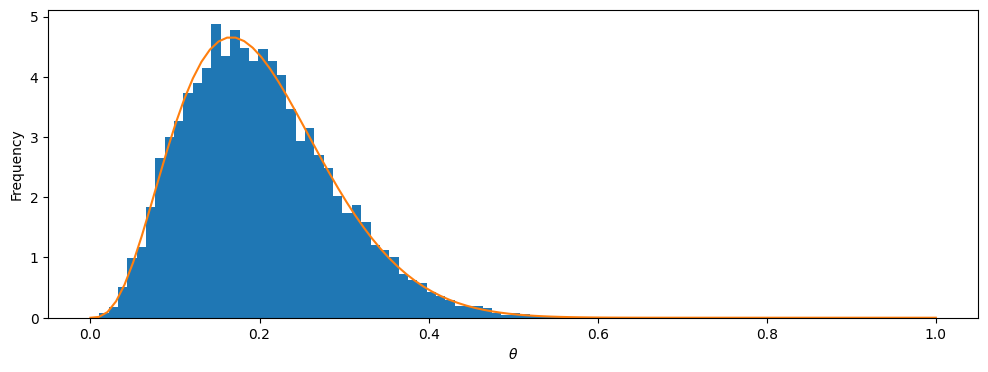

In [35]:
Posterior = np.random.beta(a, b, 10_000)
plt.figure(figsize=(6*2,4))
plt.hist(Posterior, bins = "auto", density=True)
plt.plot(np.linspace(0,1,100),st.beta.pdf(np.linspace(0,1,100),a,b))
plt.xlabel(r"$\theta$")
plt.ylabel("Frequency");

In [27]:
# Intervalo de credibilidad
np.percentile(Posterior,[2.5,97.5])

array([0.06192157, 0.39325893])

In [36]:
print(1-stats.beta.cdf(0.2,a,b))
print(np.mean(Posterior > 0.20))
print(Posterior[Posterior >=0.2].size/Posterior.size)

0.4550887423457882
0.46
0.46


$$M_i = a+b\log_{10}(P_i) + \varepsilon_i$$

In [46]:
df = pd.read_csv("mw_cepheids.csv")

In [44]:
df = df.drop("Imag",axis=1) # elimina ultima columna
df = df.dropna() # elimina filas con Na

In [49]:
df.columns

Index(['_RAJ2000', '_DEJ2000', 'Per', 'plx', 'Vmag', 'Imag'], dtype='object')

Continuar con el notebook del profesor

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

# 1. Carga de datos (ajustar nombres de columnas si es necesario)
df = pd.read_csv('cepheids_2.csv')
x = np.log10(df['P'].values)
M = df['M'].values
n = len(x)

# Parámetros del modelo
sigma = 0.3
tau = 10.0

# Matriz de diseño X = [1, x]
X = np.column_stack((np.ones(n), x))

# 2. Distribución posterior conjunta (Normal Bivariada)
# Sigma_post = (X^T X / sigma^2 + I / tau^2)^-1
Sigma_inv = (X.T @ X) / sigma**2 + np.eye(2) / tau**2
Sigma_post = np.linalg.inv(Sigma_inv)
mu_post = Sigma_post @ (X.T @ M) / sigma**2
a_map, b_map = mu_post

# 3. Regresión lineal clásica (MCO) para comparación
beta_ols = np.linalg.inv(X.T @ X) @ X.T @ M

# 4. Gráficos
x_plot = np.linspace(x.min(), x.max(), 100)
X_plot = np.column_stack((np.ones_like(x_plot), x_plot))

# Media de la recta MAP
M_mean = X_plot @ mu_post

# Banda de credibilidad del 95% para la media
var_mean = np.sum((X_plot @ Sigma_post) * X_plot, axis=1)
std_mean = np.sqrt(var_mean)
z = st.norm.ppf(0.975)

plt.figure(figsize=(8, 5))
plt.scatter(x, M, color='gray', s=20, label='Datos Cefeidas')
plt.plot(x_plot, M_mean, 'r-', lw=2, label=f'MAP: M = {a_map:.2f} {b_map:+.2f}x')
plt.fill_between(x_plot, M_mean - z*std_mean, M_mean + z*std_mean, color='red', alpha=0.2, label='Banda de credibilidad 95%')

# Recta MCO
M_ols = X_plot @ beta_ols
plt.plot(x_plot, M_ols, 'b--', lw=1.5, label=f'MCO: M = {beta_ols[0]:.2f} {beta_ols[1]:+.2f}x')

plt.xlabel(r'$x = \log_{10}(P)$')
plt.ylabel('Magnitud Absoluta $M$')
plt.title('Relación Período-Luminosidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()